In [ ]:
!pip install kagglehub

In [ ]:
!pip install kaggle seaborn plotly

Download dataset via API

In [ ]:
import kagglehub

path = kagglehub.dataset_download("atharvasoundankar/smart-farming-sensor-data-for-yield-prediction")

print("Path to dataset files:", path)

100%|██████████| 27.7k/27.7k [00:00<00:00, 34.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/atharvasoundankar/smart-farming-sensor-data-for-yield-prediction/versions/1


In [ ]:
#Copy ke raw folder
import shutil
import os

os.makedirs("data/raw", exist_ok=True)

for file in os.listdir(path):
    shutil.copy(os.path.join(path, file), "data/raw")

Load Data

In [ ]:
import pandas as pd

df = pd.read_csv("/content/data/raw/Smart_Farming_Crop_Yield_2024.csv")
df.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,...,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status
0,FARM0001,North India,Wheat,35.95,5.99,17.79,75.62,77.03,7.27,NaN,...,2024-01-08,2024-05-09,122,4408.07,SENS0001,2024-03-19,14.970941,82.997689,0.63,Mild
1,FARM0002,South USA,Soybean,19.74,7.24,30.18,89.91,61.13,5.67,Sprinkler,...,2024-02-04,2024-05-26,112,5389.98,SENS0002,2024-04-21,16.613022,70.869009,0.58,NaN
2,FARM0003,South USA,Wheat,29.32,7.16,27.37,265.43,68.87,8.23,Drip,...,2024-02-03,2024-06-26,144,2931.16,SENS0003,2024-02-28,19.503156,79.068206,0.80,Mild
3,FARM0004,Central USA,Maize,17.33,6.03,33.73,212.01,70.46,5.03,Sprinkler,...,2024-02-21,2024-07-04,134,4227.80,SENS0004,2024-05-14,31.071298,85.519998,0.44,NaN
4,FARM0005,Central USA,Cotton,19.37,5.92,33.86,269.09,55.73,7.93,NaN,...,2024-02-05,2024-05-20,105,4979.96,SENS0005,2024-04-13,16.568540,81.691720,0.84,Severe


# **EDA**

In [ ]:
#Info Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   farm_id               500 non-null    object 
 1   region                500 non-null    object 
 2   crop_type             500 non-null    object 
 3   soil_moisture_%       500 non-null    float64
 4   soil_pH               500 non-null    float64
 5   temperature_C         500 non-null    float64
 6   rainfall_mm           500 non-null    float64
 7   humidity_%            500 non-null    float64
 8   sunlight_hours        500 non-null    float64
 9   irrigation_type       350 non-null    object 
 10  fertilizer_type       500 non-null    object 
 11  pesticide_usage_ml    500 non-null    float64
 12  sowing_date           500 non-null    object 
 13  harvest_date          500 non-null    object 
 14  total_days            500 non-null    int64  
 15  yield_kg_per_hectare  5

In [ ]:
#Describe
df.describe()

,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,pesticide_usage_ml,total_days,yield_kg_per_hectare,latitude,longitude,NDVI_index
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,26.750140,6.523980,24.675740,181.685740,65.194460,7.03014,26.586980,119.496000,4032.92694,22.442473,80.392248,0.602060
std,10.150053,0.585558,5.348899,72.293091,14.642849,1.69167,13.202429,16.798046,1174.43304,7.283492,5.910664,0.175402
min,10.160000,5.510000,15.000000,50.170000,40.230000,4.01000,5.050000,90.000000,2023.56000,10.004243,70.020021,0.300000
25%,17.890000,6.030000,20.295000,119.217500,51.865000,5.66750,14.945000,105.750000,2994.82000,16.263202,75.374713,0.447500
50%,25.855000,6.530000,24.655000,191.545000,65.685000,6.99500,25.980000,119.000000,4071.69000,21.981743,80.650284,0.610000
75%,36.022500,7.040000,29.090000,239.035000,77.995000,8.47000,38.005000,134.000000,5062.11000,28.528948,85.654629,0.750000
max,44.980000,7.500000,34.840000,298.960000,90.000000,10.00000,49.940000,150.000000,5998.29000,34.981531,89.991901,0.900000


In [ ]:
#Missing Value
df.isnull().sum()

,0
farm_id,0
region,0
crop_type,0
soil_moisture_%,0
soil_pH,0
temperature_C,0
rainfall_mm,0
humidity_%,0
sunlight_hours,0
irrigation_type,150


# **Data Cleaning**

In [ ]:
#Handling mv
df = df.fillna(df.median(numeric_only=True))

In [ ]:
#Convert Timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [ ]:
#Remove outlier - IQR
numeric_cols = df.select_dtypes(include=['number']).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# For each numeric column, check if values are outside the IQR range
outlier_mask = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

# Filter the DataFrame to remove rows with outliers
df = df[~outlier_mask]

df['irrigation_type'] = df['irrigation_type'].fillna(df['irrigation_type'].mode()[0])
df['crop_disease_status'] = df['crop_disease_status'].fillna(df['crop_disease_status'].mode()[0])
df['sowing_date'] = pd.to_datetime(df['sowing_date'])
df['harvest_date'] = pd.to_datetime(df['harvest_date'])

In [ ]:
df.dtypes

,0
farm_id,object
region,object
crop_type,object
soil_moisture_%,float64
soil_pH,float64
temperature_C,float64
rainfall_mm,float64
humidity_%,float64
sunlight_hours,float64
irrigation_type,object


**Validasi Data**

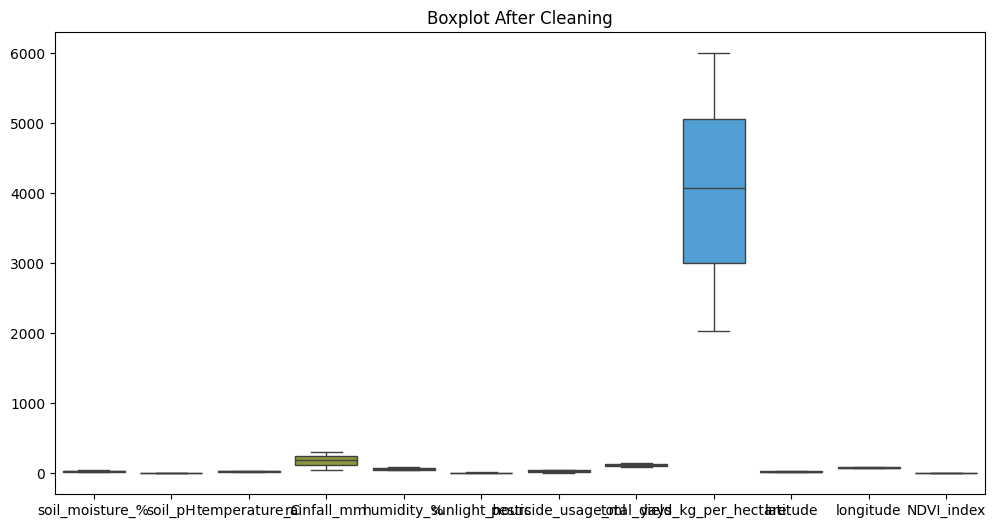

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Boxplot After Cleaning")
plt.show()

In [ ]:
#Range nilai
print("Soil Moisture:", df['soil_moisture_%'].min(), "-", df['soil_moisture_%'].max())
print("Temperature:", df['temperature_C'].min(), "-", df['temperature_C'].max())
print("Humidity:", df['humidity_%'].min(), "-", df['humidity_%'].max())

Soil Moisture: 10.16 - 44.98
Temperature: 15.0 - 34.84
Humidity: 40.23 - 90.0


In [ ]:
#Cek waktu
df = df.sort_values("timestamp")
df['timestamp'].diff().describe()

,timestamp
count,499
mean,0 days 10:40:38.476953907
std,1 days 00:07:32.887451827
min,0 days 00:00:00
25%,0 days 00:00:00
50%,0 days 00:00:00
75%,1 days 00:00:00
max,16 days 00:00:00


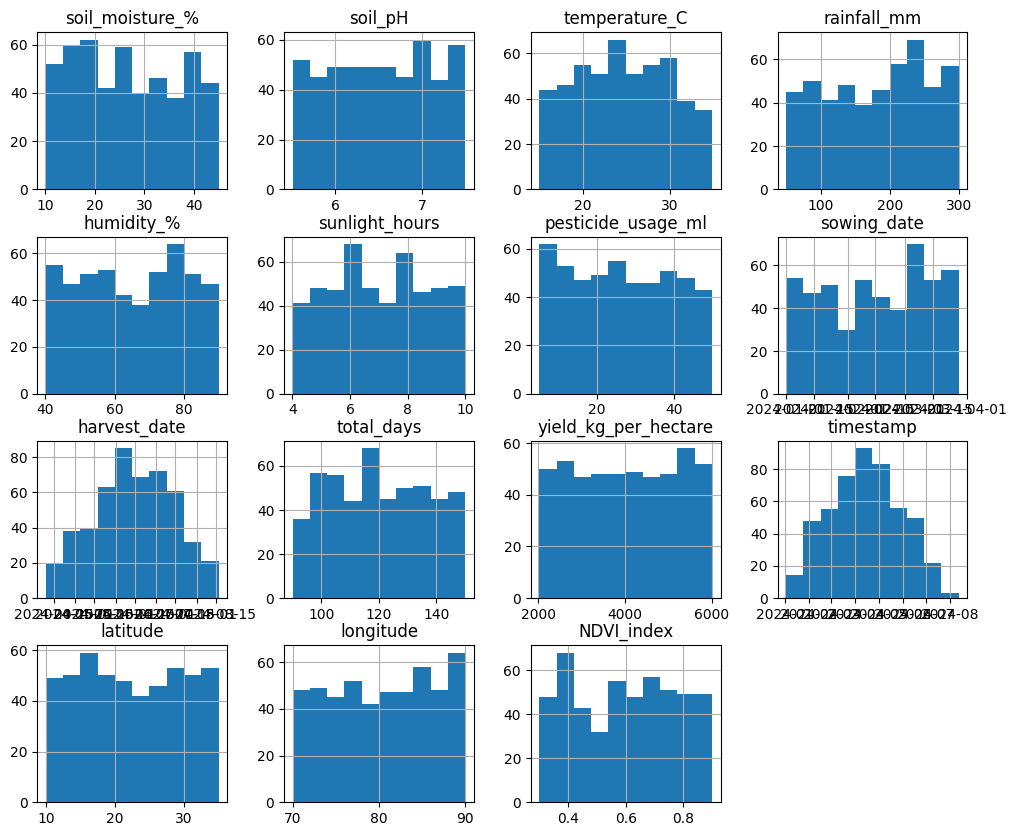

In [ ]:
df.hist(figsize=(12,10))
plt.show()

**Analisis**

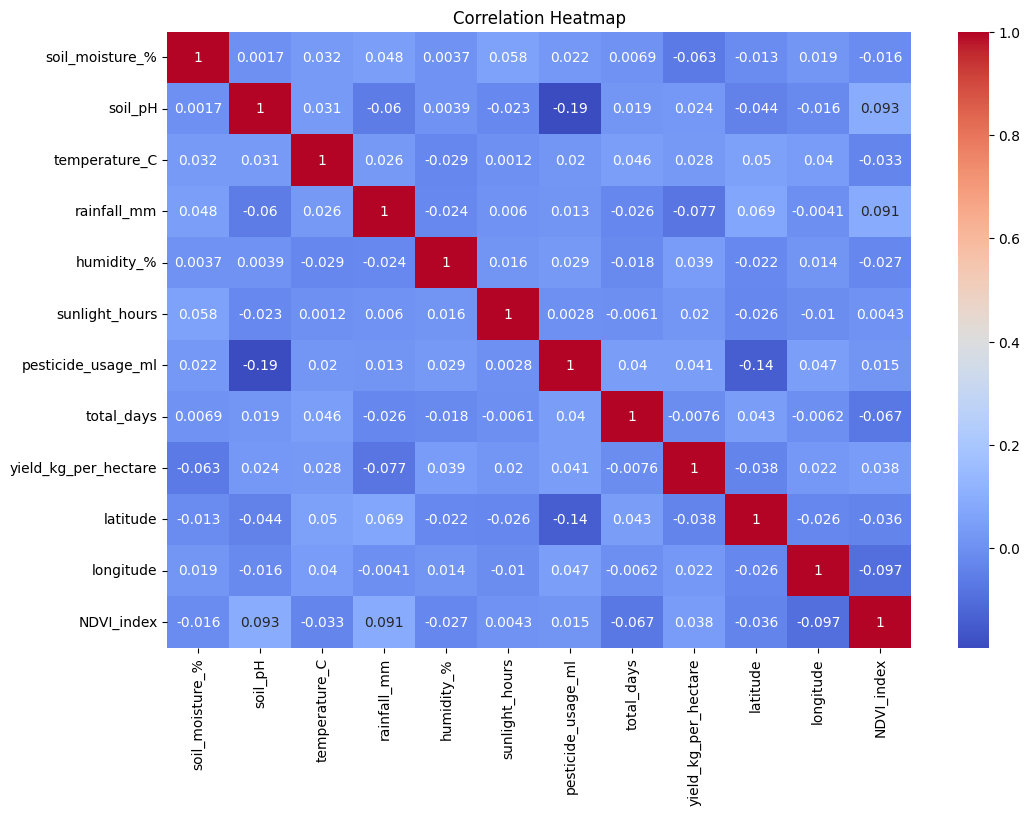

In [ ]:
#Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['float64','int64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df['timestamp'].diff().describe()

,timestamp
count,499
mean,0 days 10:40:38.476953907
std,1 days 00:07:32.887451827
min,0 days 00:00:00
25%,0 days 00:00:00
50%,0 days 00:00:00
75%,1 days 00:00:00
max,16 days 00:00:00


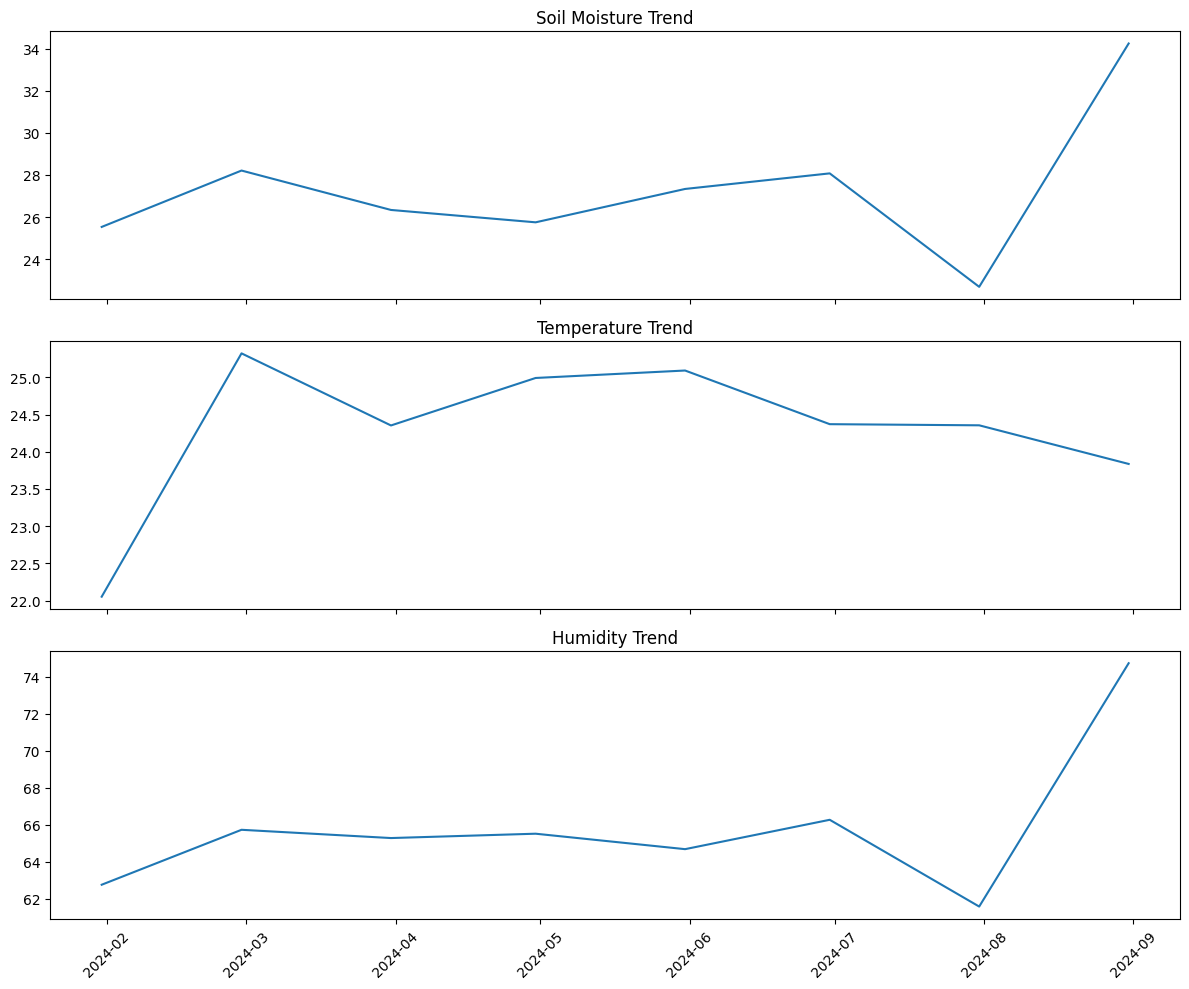

In [ ]:
import matplotlib.pyplot as plt

# Tren bulanan
df_daily = df[['soil_moisture_%', 'temperature_C', 'humidity_%']].resample('ME').mean()

fig, ax = plt.subplots(3, 1, figsize=(12,10), sharex=True)

ax[0].plot(df_daily.index, df_daily['soil_moisture_%'])
ax[0].set_title("Soil Moisture Trend")

ax[1].plot(df_daily.index, df_daily['temperature_C'])
ax[1].set_title("Temperature Trend")

ax[2].plot(df_daily.index, df_daily['humidity_%'])
ax[2].set_title("Humidity Trend")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

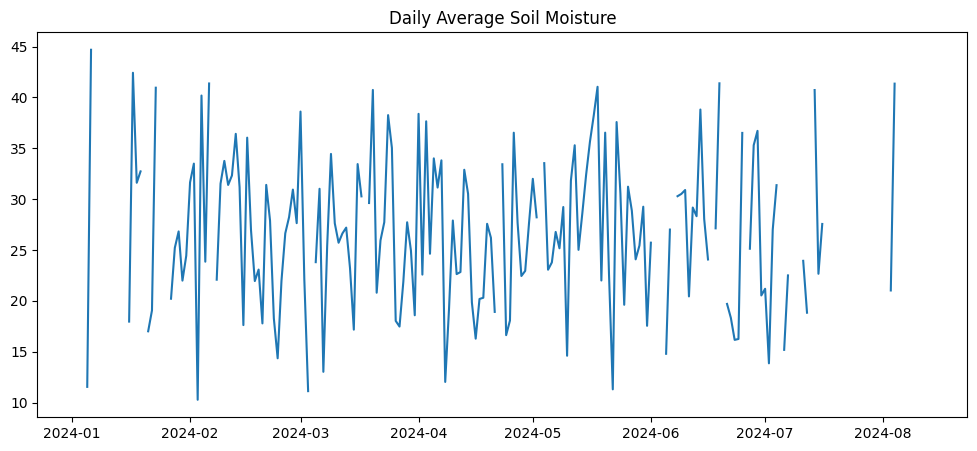

In [ ]:
# Visualisasi Tren Kelembaban Tanah Harian
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

daily = df['soil_moisture_%'].resample('D').mean()

plt.figure(figsize=(12,5))
plt.plot(daily)
plt.title("Daily Average Soil Moisture")
plt.show()

**Simpan** **Clean** **Data**

In [ ]:
df.to_csv("cleaned_data.csv", index=False)